In [2]:
import cv2
import kornia as K
import kornia.feature as KF
import matplotlib.pyplot as plt
import numpy as np
import torch
from kornia_moons.viz import draw_LAF_matches
from kornia.feature import LoFTR

In [3]:
osm_png_path = r"C:\Users\arber\Desktop\georeferencer\georeferencer\LoFTR_map_georeferencer\osm_ref.png"
bplan_png_path = r"C:\Users\arber\Desktop\georeferencer\georeferencer\LoFTR_map_georeferencer\output\bplan_clipped.png"
liegenschaft_png_path = r"C:\Users\arber\Desktop\georeferencer\georeferencer\LoFTR_map_georeferencer\output\liegenschaftkataster.png"

In [21]:
# Load images and convert RGBA to RGB if needed
img1_raw = cv2.imread(liegenschaft_png_path, cv2.IMREAD_COLOR)  # Force RGB loading
img2_raw = cv2.imread(bplan_png_path, cv2.IMREAD_COLOR)  # Force RGB loading

# Convert BGR to RGB and then to tensor
img1_raw = cv2.cvtColor(img1_raw, cv2.COLOR_BGR2RGB)
img2_raw = cv2.cvtColor(img2_raw, cv2.COLOR_BGR2RGB)

# Convert to torch tensors
img1 = K.utils.image_to_tensor(img1_raw, keepdim=False).float() / 255.0
img2 = K.utils.image_to_tensor(img2_raw, keepdim=False).float() / 255.0

img1 = img1[None, ...]  # Add batch dimension
img2 = img2[None, ...]  # Add batch dimension

img1 = K.geometry.resize(img1, (512, 512), antialias=True)
img2 = K.geometry.resize(img2, (512, 512), antialias=True)




In [22]:
matcher = LoFTR(pretrained="outdoor")

In [23]:
# Check RGB tensor shapes first
print(f"img1 shape before grayscale: {img1.shape}")
print(f"img2 shape before grayscale: {img2.shape}")

# Convert to grayscale - LoFTR expects single channel images
gray1 = K.color.rgb_to_grayscale(img1)
gray2 = K.color.rgb_to_grayscale(img2)

# Check shapes after grayscale
print(f"gray1 shape after grayscale: {gray1.shape}")
print(f"gray2 shape after grayscale: {gray2.shape}")

# Ensure correct shape [B, 1, H, W] - squeeze any extra dimensions
if gray1.dim() == 5:
    gray1 = gray1.squeeze(2)
    gray2 = gray2.squeeze(2)
    print(f"After squeeze - gray1: {gray1.shape}, gray2: {gray2.shape}")

input_dict = {
    "image0": gray1,
    "image1": gray2,
}

img1 shape before grayscale: torch.Size([1, 1, 3, 512, 512])
img2 shape before grayscale: torch.Size([1, 1, 3, 512, 512])
gray1 shape after grayscale: torch.Size([1, 1, 1, 512, 512])
gray2 shape after grayscale: torch.Size([1, 1, 1, 512, 512])
After squeeze - gray1: torch.Size([1, 1, 512, 512]), gray2: torch.Size([1, 1, 512, 512])


In [27]:
with torch.inference_mode():
    correspondences = matcher(input_dict)
    
mkpts0 = correspondences["keypoints0"].cpu().numpy()
mkpts1 = correspondences["keypoints1"].cpu().numpy()

# Optional: Confidence scores (wenn verfügbar)
if "confidence" in correspondences:
    confidence = correspondences["confidence"].cpu().numpy()
    print(f"Confidence scores range: [{confidence.min():.3f}, {confidence.max():.3f}]")

print(f"Total matches gefunden: {len(mkpts0)}")

Confidence scores range: [0.200, 0.963]
Total matches gefunden: 349


In [29]:
# ========================================
# HIER kannst du die Anzahl der Punkte kontrollieren
# ========================================

# Option 1: Limitiere auf maximale Anzahl (z.B. Top 500 Punkte)
MAX_POINTS = 100  # Ändere diese Zahl

if len(mkpts0) > MAX_POINTS:
    # Option 1a: Nimm zufällige Punkte
    # indices = np.random.choice(len(mkpts0), MAX_POINTS, replace=False)
    
    # Option 1b: Nimm die ersten N Punkte
    indices = np.arange(MAX_POINTS)
    
    # Option 1c: Wenn Confidence verfügbar, nimm die besten Punkte
    if "confidence" in correspondences:
        confidence = correspondences["confidence"].cpu().numpy()
        indices = np.argsort(confidence)[::-1][:MAX_POINTS]  # Top MAX_POINTS mit höchstem Score
    
    mkpts0 = mkpts0[indices]
    mkpts1 = mkpts1[indices]
    print(f"Reduziert auf {MAX_POINTS} Punkte")
else:
    print(f"Alle {len(mkpts0)} Punkte werden verwendet")

# Option 2: Filtere nach Confidence-Schwellwert
# if "confidence" in correspondences:
#     confidence = correspondences["confidence"].cpu().numpy()
#     CONFIDENCE_THRESHOLD = 0.5  # Nur Matches mit confidence > 0.5
#     mask = confidence > CONFIDENCE_THRESHOLD
#     mkpts0 = mkpts0[mask]
#     mkpts1 = mkpts1[mask]
#     print(f"Nach Confidence-Filter: {len(mkpts0)} Punkte")

Reduziert auf 100 Punkte


In [30]:
# RANSAC Parameter - hier kannst du auch die Qualität der Matches beeinflussen
# 0.5 = Pixel-Threshold (niedriger = strenger)
# 0.999 = Confidence (höher = mehr Iterations für bessere Ergebnisse)
Fm, inliers = cv2.findFundamentalMat(mkpts0, mkpts1, cv2.USAC_MAGSAC, 0.5, 0.999, 100000)
inliers = inliers > 0

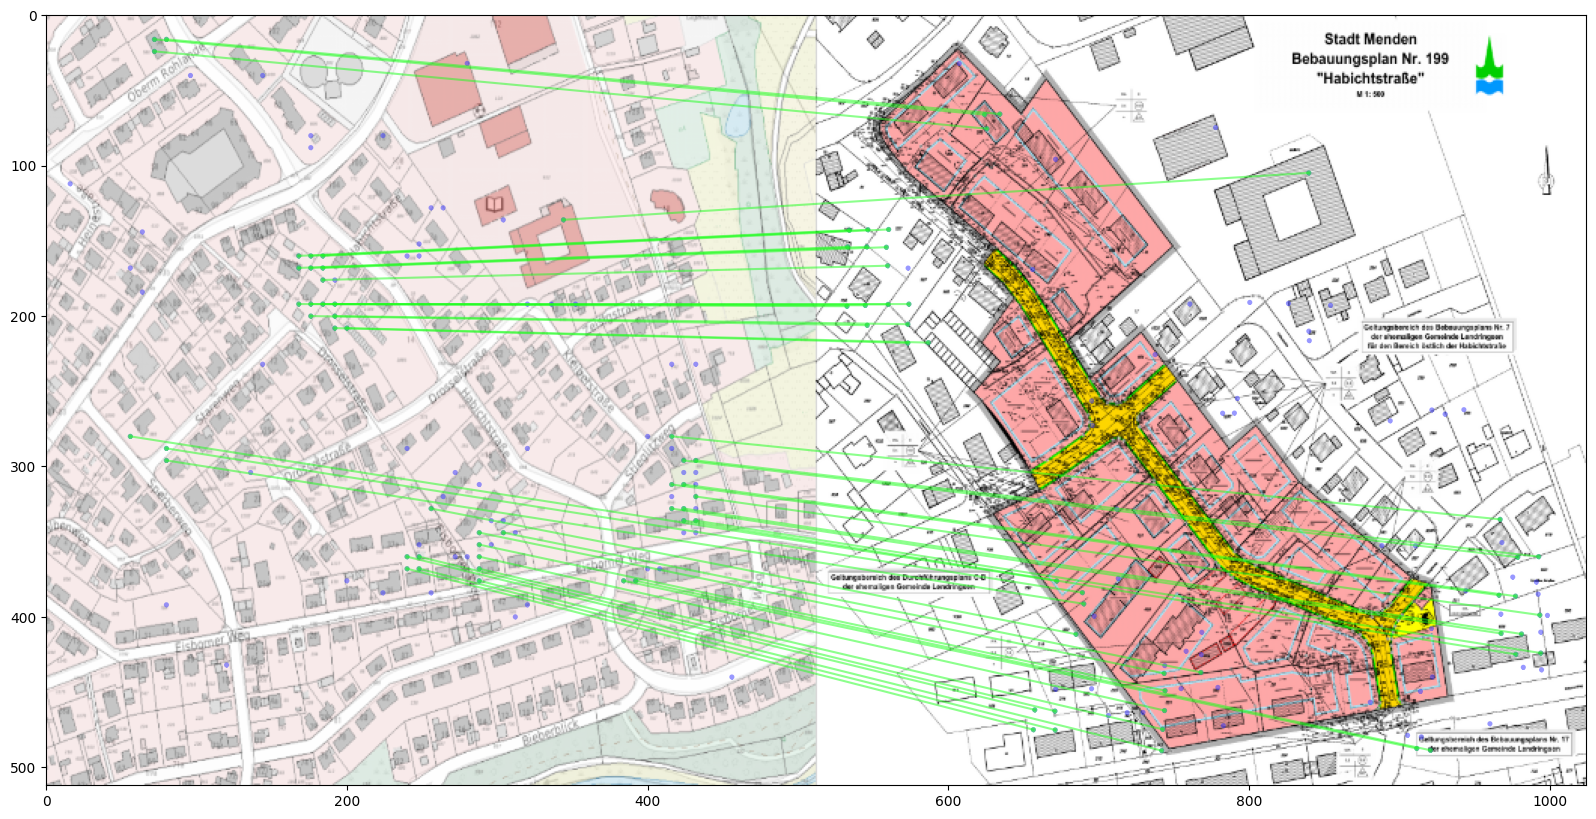

In [31]:
draw_LAF_matches(
    KF.laf_from_center_scale_ori(
        torch.from_numpy(mkpts0).view(1, -1, 2),
        torch.ones(mkpts0.shape[0]).view(1, -1, 1, 1),
        torch.ones(mkpts0.shape[0]).view(1, -1, 1),
    ),
    KF.laf_from_center_scale_ori(
        torch.from_numpy(mkpts1).view(1, -1, 2),
        torch.ones(mkpts1.shape[0]).view(1, -1, 1, 1),
        torch.ones(mkpts1.shape[0]).view(1, -1, 1),
    ),
    torch.arange(mkpts0.shape[0]).view(-1, 1).repeat(1, 2),
    K.tensor_to_image(img1[0]),  # Remove batch dimension: [3, 512, 512]
    K.tensor_to_image(img2[0]),  # Remove batch dimension: [3, 512, 512]
    inliers,
    draw_dict={
        "inlier_color": (0.1, 1, 0.1, 0.5),
        "tentative_color": None,
        "feature_color": (0.2, 0.2, 1, 0.5),
        "vertical": False,
    },
)

plt.show()